# The Data Processing Code to Get the Link Time from ASDEX Data

In [26]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from sedona.register import SedonaRegistrator
from sedona.utils import SedonaKryoRegistrator, KryoSerializer
from sedona.spark import *

config = SedonaContext.builder(). \
    config('spark.jars.packages',
           'org.apache.sedona:sedona-spark-3.3_2.12:1.7.0,'
           'org.datasyslab:geotools-wrapper:1.7.0-28.5'). \
    config('spark.jars.repositories', 'https://artifacts.unidata.ucar.edu/repository/unidata-all'). \
    getOrCreate()
sedona = SedonaContext.create(config)

spark = SparkSession.\
        builder.\
        master("local[*]").\
        appName("Sector_IFF_Parser").\
        config("spark.serializer", KryoSerializer.getName).\
        config("spark.kryo.registrator", SedonaKryoRegistrator.getName) .\
        config("spark.driver.memory", "150g") .\
        config("spark.executor.memory", "150g") .\
        config("spark.executor.instances", "40") .\
        config("spark.jars.packages", "org.apache.sedona:sedona-python-adapter-3.0_2.12:1.0.0-incubating,org.datasyslab:geotools-wrapper:geotools-24.0") .\
        getOrCreate()

SedonaRegistrator.registerAll(spark)
sc = spark.sparkContext

def load_schema():
    myschema = StructType([
        StructField("recType", ShortType(), True),  # 1  //track point record type number
        StructField("recTime", StringType(), True),  # 2  //seconds since midnigght 1/1/70 UTC
        StructField("fltKey", LongType(), True),  # 3  //flight key
        StructField("bcnCode", IntegerType(), True),  # 4  //digit range from 0 to 7
        StructField("cid", IntegerType(), True),  # 5  //computer flight id
        StructField("Source", StringType(), True),  # 6  //source of the record
        StructField("msgType", StringType(), True),  # 7
        StructField("acId", StringType(), True),  # 8  //call sign
        StructField("recTypeCat", IntegerType(), True),  # 9
        StructField("lat", DoubleType(), True),  # 10
        StructField("lon", DoubleType(), True),  # 11
        StructField("alt", DoubleType(), True),  # 12  //in 100s of feet
        StructField("significance", ShortType(), True),  # 13 //digit range from 1 to 10
        StructField("latAcc", DoubleType(), True),  # 14
        StructField("lonAcc", DoubleType(), True),  # 15
        StructField("altAcc", DoubleType(), True),  # 16
        StructField("groundSpeed", IntegerType(), True),  # 17 //in knots
        StructField("course", DoubleType(), True),  # 18  //in degrees from true north
        StructField("rateOfClimb", DoubleType(), True),  # 19  //in feet per minute
        StructField("altQualifier", StringType(), True),  # 20  //Altitude qualifier (the “B4 character”)
        StructField("altIndicator", StringType(), True),  # 21  //Altitude indicator (the “C4 character”)
        StructField("trackPtStatus", StringType(), True),  # 22  //Track point status (e.g., ‘C’ for coast)
        StructField("leaderDir", IntegerType(), True),  # 23  //int 0-8 representing the direction of the leader line
        StructField("scratchPad", StringType(), True),  # 24
        StructField("msawInhibitInd", ShortType(), True),  # 25 // MSAW Inhibit Indicator (0=not inhibited, 1=inhibited)
        StructField("assignedAltString", StringType(), True),  # 26
        StructField("controllingFac", StringType(), True),  # 27
        StructField("controllingSec", StringType(), True),  # 28
        StructField("receivingFac", StringType(), True),  # 29
        StructField("receivingSec", StringType(), True),  # 30
        StructField("activeContr", IntegerType(), True),  # 31  // the active control number
        StructField("primaryContr", IntegerType(), True),
        # 32  //The primary(previous, controlling, or possible next)controller number
        StructField("kybrdSubset", StringType(), True),  # 33  //identifies a subset of controller keyboards
        StructField("kybrdSymbol", StringType(), True),  # 34  //identifies a keyboard within the keyboard subsets
        StructField("adsCode", IntegerType(), True),  # 35  //arrival departure status code
        StructField("opsType", StringType(), True),  # 36  //Operations type (O/E/A/D/I/U)from ARTS and ARTS 3A data
        StructField("airportCode", StringType(), True),  # 37
        StructField("trackNumber", IntegerType(), True),  # 38
        StructField("tptReturnType", StringType(), True),  # 39
        StructField("modeSCode", StringType(), True)  # 40
    ])
    return myschema

iff_schema = load_schema()


25/01/24 12:33:56 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.
25/01/24 12:33:56 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/01/24 12:33:56 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/01/24 12:33:56 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/01/24 12:33:56 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/01/24 12:33:56 WARN SimpleFunctionRegistry: The function st_envelope_aggr replaced a previously registered function.
25/01/24 12:33:56 WARN SimpleFunctionRegistry: The function st_intersection_aggr replaced a previously registered function.
25/01/24 12:33:56 WARN SimpleFunctionRegistry: The function st_union_aggr replaced a previously registered function.
25/

In [27]:
# The date of ASDE-X we are going to process
date = '20220127'
# The path to the csv file
data_path = "/home/yp6443/research/ProceduresTP/RawData/IFF_2022_01_01_2022_03_31_ZTL/IFF_ZTL_{}*.csv".format(date)
df = spark.read.csv(data_path, header=False, sep=",", schema=iff_schema)

In [28]:
KATL = [33.6366996, -84.4278640, 10]

df.registerTempTable("orginaldatatable")

df_result = spark.sql(
    """
    SELECT acId,
           recTime - (SELECT MIN(recTime) FROM orginaldatatable) AS time,
           lat, 
           lon, 
           alt
    FROM orginaldatatable
    WHERE alt < {}
    """.format(KATL[2] + 1)
)

df_result.count()

5339

In [29]:
df_result.show()

+-------+------------------+--------+---------+----+
|   acId|              time|     lat|      lon| alt|
+-------+------------------+--------+---------+----+
|AAL1050|16253.801000118256|33.54722|-86.78444|10.0|
|AAL1050|16263.801000118256|33.55028|-86.77944| 9.0|
|AAL1050|16280.801000118256|33.55556|-86.77028| 9.0|
|AAL1050|16295.801000118256|   33.56|-86.76278| 9.0|
|AAL1050|16311.801000118256|33.56444|  -86.755| 9.0|
|FDX1052|16646.801000118256|36.08861|-79.94806|10.0|
|FDX1052|16655.801000118256|36.09222|-79.94361| 9.0|
|FDX1052|16668.801000118256|36.09806| -79.9375| 9.0|
|FDX1052|16684.801000118256|36.10417|-79.93028| 9.0|
| NKS631|16949.801000118256|33.63167|-84.42389| 9.0|
| NKS631|16955.801000118256|33.63167|-84.42778| 9.0|
|ENY4393|17309.801000118256|33.54806|-86.78333|10.0|
|ENY4393|17318.801000118256|33.55194|-86.77667| 8.0|
|ENY4393|17337.801000118256|33.55639|-86.76889| 8.0|
|ENY4393|17352.801000118256|33.56083|-86.76111| 8.0|
|ENY4393|17367.801000118256|33.56528|-86.75361

# User Surface Data

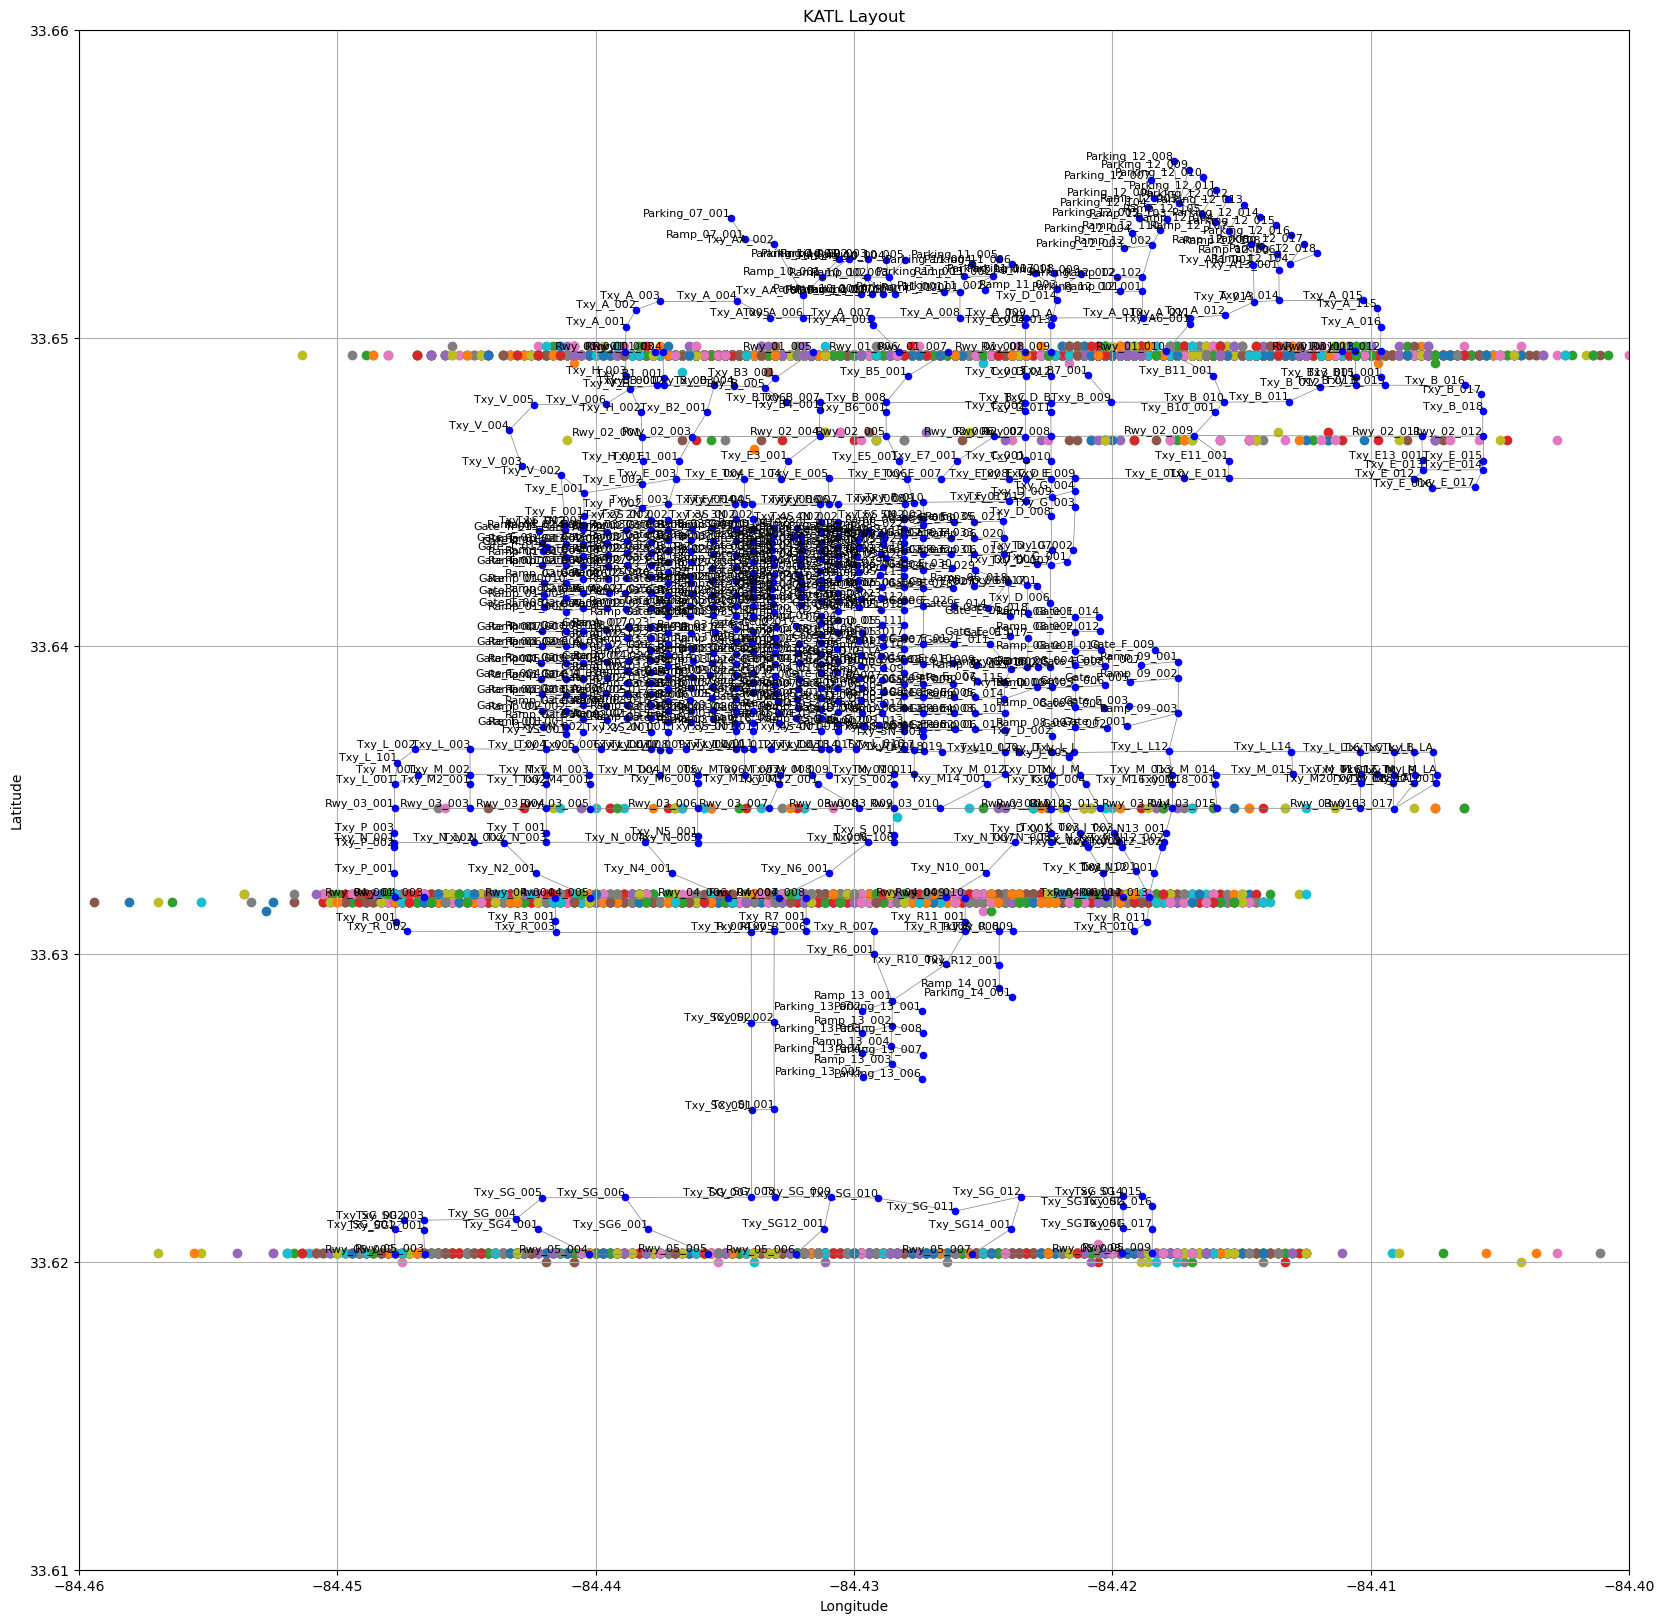

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os, glob

KATL = [33.6366996, -84.4278640, 10]
data_path = '/home/yp6443/research/nlp/surface_data/2022-01-27/true_pos_.csv'
data_paths = glob.glob('/home/yp6443/research/nlp/surface_data/*/true_pos_.csv')

# Plot the first 5 agents' positions
plt.figure(figsize=(20, 20))

for data_path in data_paths:
    # Load the CSV file
    df = pd.read_csv(data_path, header=None).T

    # Assign meaningful column names
    df.columns = ['time', 'acid', 'lat', 'lon']

    # Convert columns to appropriate types
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df['adid'] = df['acid'].astype(str)
    df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
    df['lon'] = pd.to_numeric(df['lon'], errors='coerce')

    # Select only the first 5 unique agents
    first_5_agents = df['acid'].unique()[:]
    df_filtered = df[df['acid'].isin(first_5_agents)]

    for agent_id, agent_data in df_filtered.groupby('acid'):
        plt.scatter(agent_data['lon'], agent_data['lat'], label=f'Agent {agent_id}')


airport = 'KATL'
filePath = os.getcwd() + '/Airport Layouts/' + airport + '_Nodes_Links.csv'
linksDf = pd.read_csv(filePath)
# Combine nodes and drop duplicates
nodes = pd.concat([
    linksDf[['n1.id', 'n1.lat', 'n1.lon']].rename(columns={'n1.id': 'id', 'n1.lat': 'lat', 'n1.lon': 'lon'}),
    linksDf[['n2.id', 'n2.lat', 'n2.lon']].rename(columns={'n2.id': 'id', 'n2.lat': 'lat', 'n2.lon': 'lon'})
]).drop_duplicates()

# Create a dictionary of node positions
nodePositions = {row['id']: (row['lat'], row['lon']) for _, row in nodes.iterrows()}

# Plot the links
for _, row in linksDf.iterrows():
    n1Pos = (row['n1.lat'], row['n1.lon'])
    n2Pos = (row['n2.lat'], row['n2.lon'])
    plt.plot([n1Pos[1], n2Pos[1]], [n1Pos[0], n2Pos[0]], color='gray', linestyle='-', linewidth=0.5)

# Plot the nodes
for nodeId, (lat, lon) in nodePositions.items():
    plt.scatter(lon, lat, color='blue', s=20, zorder=2)
    plt.text(lon, lat, nodeId, fontsize=8, ha='right', va='bottom')


plt.axis([-84.46, -84.4, 33.61, 33.66])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(str(airport) + ' Layout')
# plt.legend()
plt.grid(True)
plt.show()